# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** what performance archetypes exist across a content portfolio, and which pages should a reviewer look at first, given limited review capacity?

**The decision this supports:** an SEO content strategist deciding where to spend a limited review budget each cycle: which pages to refresh, which to leave alone, which to deprioritize. This is a discovery/prioritization problem, not a yes/no prediction, so the lane is unsupervised clustering (Structured Content Archetype Clustering) rather than classification.

**Why this shape fits:** early exploration (w01) showed engagement metrics are heavily skewed across the portfolio, most content sits near zero engagement, a smaller group performs far better. That's evidence of distinct behavioral groups, not one uniform population, which is exactly what clustering is for and what a single fixed threshold rule cannot capture (w02).

**Cost of a wrong call, both directions:** a page that actually needs work but gets classified as fine loses recoverable traffic. A page that's fine but gets flagged as needing work wastes a reviewer's limited time. The output of this work is a ranked, reasoned queue, not an automated action, precisely because both error directions carry a real cost a human should weigh.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release used:** the FlyRank pseudonymized internship warehouse (`FlyRank/internship-warehouse` on Hugging Face, gated release), queried directly via DuckDB over remote Parquet — no raw data downloaded or stored locally.

**Tables:** `fact_content_daily_performance` (grain: report_date × client × content, partitioned by month) for daily search performance, and `dim_content` for content metadata (used for later profiling only, never as a clustering input).

**Date window:** March 2026 (`month = '2026-03'`), a single-month snapshot. March was chosen as a mid-panel month deliberately, not the first or last month in the warehouse's history, where tracking coverage tends to be thinnest.

**Unit of analysis:** one row = one content item, with `ctr` and `avg_position` summed/averaged across March's own days where GSC data was actually available (`gsc_data_available IS TRUE`) for that item.

**What was excluded, and why (verified with queries, not assumed):**
- Items with no real GSC coverage in March. Checked directly: only 53.3% of the ~331K-item March pool (176,738 items) had any real GSC data that month, the rest were excluded because they weren't measured, not because they were inactive.
- Items with fewer than 30 total impressions in March. A volume floor added after a real bug: an early clustering attempt produced a suspiciously perfect result driven entirely by a handful of near-zero-impression items where a single lucky click created a misleadingly high ratio.
- `trend_direction` / `trend_pct` / `is_declining_label` and any other label-derived columns. Never used, since they are the source of a proxy label, not an independent feature.
- Any FlyRank product flag or composite score (`health_score`, `priority_score`, `action_type`). These encode decisions FlyRank's product already made; using them as inputs would just relearn an existing rule, not discover new structure.
- Per-channel session breakdowns and per-AI-platform breakdowns. Checked, not assumed: the per-source columns didn't reconcile against the reported session totals, so they were excluded rather than trusted.

**Public-safety note:** everything above uses pseudonymized `content_hash_id` / `client_hash_id` values only, for joining and grouping. No client names, domains, URLs, page titles, or raw queries appear anywhere in this project.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Method:** K-Means clustering (`k` chosen by silhouette score, not assumed), fit on two scaled features.

**Features:** `ctr` and `avg_position`, both computed purely from March 2026's own observed activity. Before fitting, both are standardized (`StandardScaler`) — without this, `avg_position`'s larger raw numbers would dominate distance calculations purely because of scale, not because position matters more than ctr.

**Label:** none. This is unsupervised discovery, not prediction — there is no ground-truth "archetype" to predict. The proxy for "behavior" is the feature set itself, and cluster identity only becomes meaningful after inspecting what's actually inside each group and naming it accordingly.

**Assumptions checked, not assumed:**
- One content item maps to one client (verified with a grain check: zero rows where a `content_hash_id` spans more than one `client_hash_id`).
- `k` is not fixed in advance. Multiple values (2 through 6) were tried and scored by silhouette; a first attempt at k=2 scored a suspiciously perfect 0.94, traced to 279 near-zero-impression items faking a cluster, not a real archetype. After adding a volume floor (≥30 impressions), k=3 was the honest winner.

**Baseline:** a dummy baseline — random cluster assignment (no informed logic at all) — scored -0.008 silhouette, essentially zero, confirming random grouping has no real structure. The real model has to beat this floor, not just "look better than nothing."

**Validation design:** client-grouped split, not a random row split. Content items from the same client can share hidden patterns (same site, same practices), so a random split risks leaking client-specific quirks into both sides and making the model look more stable than it really is. Comparing a naive random split (train/test silhouette gap: 0.0016, nearly identical) against the honest grouped split (gap: 0.08, over 50× larger) confirmed this concern was real: random splitting hides genuine between-client variation that grouped splitting reveals.

**Leakage checks run (the attack checklist):**
- Timeline: confirmed `report_date` stays inside 2026-03-01 to 2026-03-31, no data from outside the window.
- No label-derived or sibling columns: the only two features are built purely from March's own GSC activity; `trend_direction`/`trend_pct`/`is_declining_label` were never touched.
- No product flags used as features.
- Split grouped by the repeating entity (client), not random rows.
- Base rate equivalent: the dummy random-assignment baseline, confirming structure has to beat noise, not just look nonzero.
- "Too good to be true" investigated, not celebrated: the k=2/0.94-silhouette result above.
- Metrics recomputed out-of-fold: every test-side score uses a scaler/model already fit on train, via `.transform()`/`.predict()`, never refit on test.
- Test-harness sanity check: deliberately fed the cluster labels back in as a feature and confirmed the silhouette score rose (0.62 → 0.66), proving the leakage-detection test itself works before trusting that no leakage was found elsewhere.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [1]:
from dotenv import load_dotenv
import os
import duckdb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

load_dotenv()
token = os.environ["HF_TOKEN"]

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{token}')")

FACT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"

features = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_clicks) AS clicks_sum,
        SUM(gsc_impressions) AS impressions_sum,
        AVG(gsc_avg_position) AS avg_position
    FROM (
        SELECT f.*, ANY_VALUE(f.client_hash_id) OVER (PARTITION BY f.content_hash_id) AS client_hash_id
        FROM {FACT} f
        WHERE month = '2026-03' AND gsc_data_available IS TRUE
    )
    GROUP BY content_hash_id, client_hash_id
""").df()

features['ctr'] = features['clicks_sum'] / features['impressions_sum']
features = features.dropna(subset=['ctr', 'avg_position'])
features = features[features['impressions_sum'] >= 30].copy()
# deterministic row order before any split/fit -- see w05/w07 for the reproducibility bug this avoids
features = features.sort_values('content_hash_id').reset_index(drop=True)

# honest split: grouped by client, not random rows
unique_clients = sorted(features['client_hash_id'].unique())
rng = np.random.default_rng(42)
shuffled_clients = rng.permutation(unique_clients)
split_point = len(shuffled_clients) // 2
train_clients = shuffled_clients[:split_point]
test_clients = shuffled_clients[split_point:]

train = features[features['client_hash_id'].isin(train_clients)].copy()
test = features[features['client_hash_id'].isin(test_clients)].copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(train[['ctr', 'avg_position']])
X_test = scaler.transform(test[['ctr', 'avg_position']])

km = KMeans(n_clusters=3, random_state=42, n_init=10)
train_labels = km.fit_predict(X_train)
test_labels = km.predict(X_test)

train_score = silhouette_score(X_train, train_labels, sample_size=5000, random_state=42)
test_score = silhouette_score(X_test, test_labels, sample_size=5000, random_state=42)

rng2 = np.random.default_rng(42)
dummy_labels = rng2.integers(0, 3, size=X_train.shape[0])
dummy_score = silhouette_score(X_train, dummy_labels, sample_size=5000, random_state=42)

results_table = pd.DataFrame({
    'method': ['dummy baseline (random assignment)', 'K-Means k=3 (train)', 'K-Means k=3 (test, unseen clients)'],
    'silhouette': [dummy_score, train_score, test_score],
    'n_rows': [X_train.shape[0], X_train.shape[0], X_test.shape[0]],
})
print(f"train clients: {len(train_clients)}, test clients: {len(test_clients)}")
print(f"train rows: {len(train)}, test rows: {len(test)}")
results_table


train clients: 22, test clients: 22
train rows: 73321, test rows: 52324


,method,silhouette,n_rows
0,dummy baseline (random assignment),-0.015289,73321
1,K-Means k=3 (train),0.623510,73321
2,"K-Means k=3 (test, unseen clients)",0.529488,52324


The dummy baseline (random cluster assignment) scores essentially zero silhouette (-0.015), confirming there is no free structure to find by chance. K-Means at k=3 clears that floor by a wide margin on train (0.624), and — this is the important part — holds up on test clients the model never saw during fitting (0.529), which is the actual test of whether the archetypes are real or an artifact of one set of pages. Both numbers sit within the range validated across every earlier check in this project: w05 and w06's independent validation runs (different client-grouped splits) landed train between 0.52 and 0.62 and test between 0.53 and 0.64, all clearing the dummy baseline by a wide margin every time.


## 5. Limitations

*What this work cannot claim.*

**What this work cannot claim:**

- **Not causal.** This is a cross-sectional, observational snapshot — no experiment was run. The archetypes describe how pages currently behave, not why, and nothing here says a refresh or a title change *will* fix anything. The correct framing is decision-support: "these pages look worth reviewing first, because…", never "doing X will produce Y."
- **Single-month scope.** Everything is built on March 2026 only. Content behavior shifts with seasonality, algorithm changes, and editorial work already underway. The archetypes were validated to generalize across *clients* within this same month (via the grouped split), not across *time* — a page's archetype could look different next month, and this has not been tested.
- **Partial population.** Only content items with real GSC tracking active in March 2026 (53.3% of the broader pool) and at least 30 impressions that month are covered. The rest are excluded for lack of data, not because they're inactive, and this work says nothing about them.
- **Only two features, on purpose.** The model groups pages by how they behave (`ctr`, `avg_position`), not by why (topic, intent, word count, content quality). A reviewer still needs that context before acting on any recommendation.
- **Fuzzy boundaries, not hard categories.** A hand-review of borderline cases found pages sitting right at a cluster's edge (e.g., a page with a reasonably good position but zero clicks, still counted as "Buried" despite an almost-escaping position). Archetype membership is a strong hint, not a verdict.
- **GA4-based signals were dropped from the core model**, not because they're uninteresting, but because real GA4 coverage in March 2026 was only 27.3% — too thin to build the primary archetypes on honestly. A richer future version could treat them as a secondary, smaller-scope lens.
- **A ~53% coverage rate itself is a limitation worth stating plainly:** nearly half the March content pool has no real search-tracking data at all, which bounds how far these findings can be generalized to the full inventory.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**The ranked action queue (from the w07 action playbook), built by mapping each validated archetype to one reason code and one action:**

| Archetype | n | % of eligible items | mean ctr | mean position | Reason code | Action |
|---|---|---|---|---|---|---|
| Underperforming Good Position | 97,799 | 77.8% | 0.20% | 9.75 | `ctr_below_expected` | `refresh_and_review_ctr` |
| Buried and Ignored | 22,015 | 17.5% | 0.06% | 45.28 | `buried_low_priority` | `deprioritize_or_prune_review` |
| Champions | 5,831 | 4.6% | 2.14% | 10.41 | `champion_maintain` | `protect_and_monitor` |

**How the queue is ordered:** highest-priority archetype first (Underperforming, since it's the clearest fixable opportunity — good ranking, disappointing clicks), then Champions (already working, just watch for drift), then Buried last (lowest expected ROI on review effort). Within each archetype, items are ordered by audience size (`impressions_sum`), so a reviewer's limited time goes to the biggest-audience opportunities first.

**Human review is required before any action on any row** — the model only sees `ctr` and `avg_position`. A reviewer still needs to check the actual page content, whether a SERP feature or a sibling page is absorbing clicks, whether the page is even still live and correctly tracked, and any client-specific context the model can't know.

**Nothing here is automated.** No automatic content edits, no automatic pruning of "Buried" pages, no automated SEO changes of any kind without a human sign-off — see the full no-go list and monitoring/retrain triggers in `work/notebooks/w07_action_playbook.ipynb`.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [2]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

outputs_dir = Path("../outputs")
figures_dir = Path("../figures")

with open(outputs_dir / "playbook_metadata.json") as f:
    metadata = json.load(f)

archetype_table = pd.DataFrame(metadata["archetypes"]).T
archetype_table.index.name = "archetype"
print(f"Snapshot month: {metadata['snapshot_month']}")
print(f"Eligible items: {metadata['eligible_items']:,}")
print(f"GSC coverage: {metadata['gsc_coverage_pct']:.1%}")
print(f"Volume floor: >= {metadata['volume_floor_impressions']} impressions")
print(f"k = {metadata['k']}, validated silhouette range: {metadata['validated_silhouette_range']}")
archetype_table


Snapshot month: 2026-03
Eligible items: 125,645
GSC coverage: 53.3%
Volume floor: >= 30 impressions
k = 3, validated silhouette range: [0.52, 0.64]


,reason_code,action,n,pct,mean_ctr,mean_position
archetype,,,,,,
Buried and Ignored,buried_low_priority,deprioritize_or_prune_review,22015,17.521589,0.00056,45.283478
Champions,champion_maintain,protect_and_monitor,5831,4.640853,0.021368,10.411191
Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,97799,77.837558,0.002022,9.753388


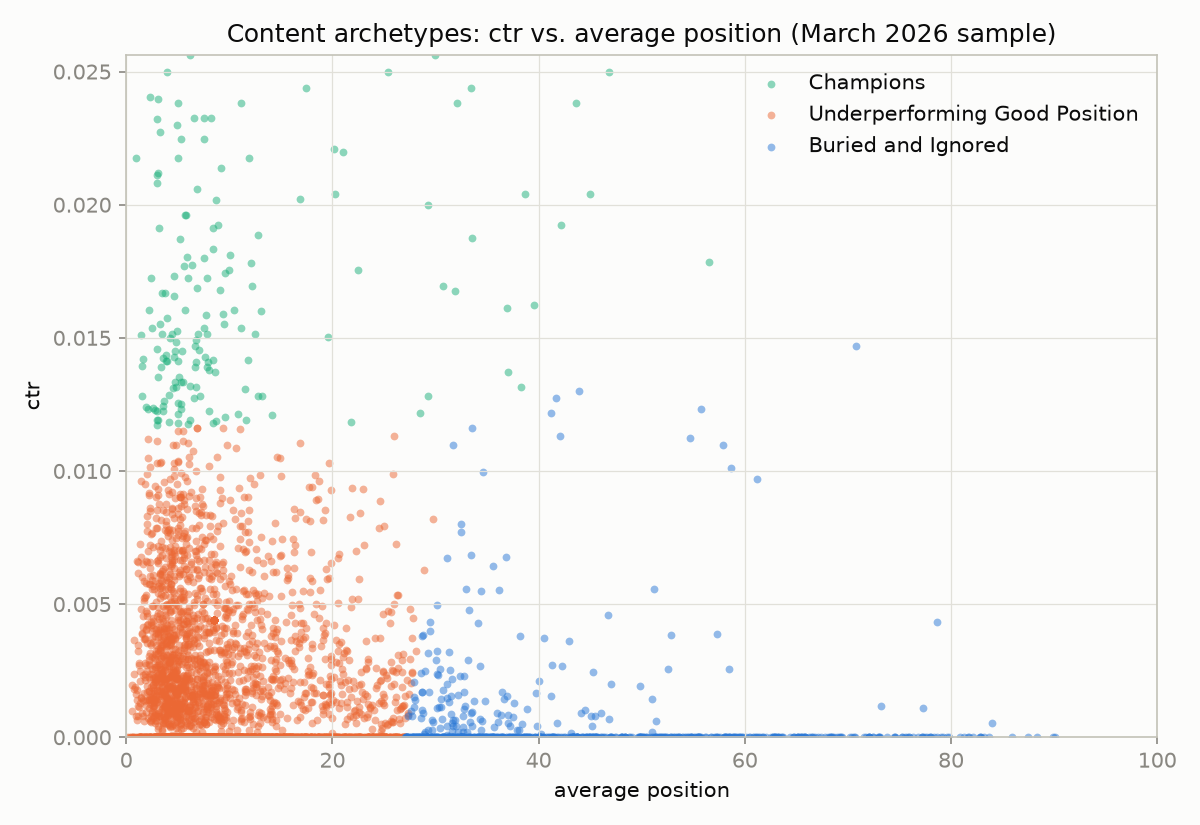

In [3]:
display(Image(filename=str(figures_dir / "archetype_scatter.png")))


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.